<hr>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
train_data = pd.read_csv('src_data/insurance.csv')
feature, label = train_data.iloc[:, :-1], train_data.iloc[:, -1]


In [3]:
print(feature.shape, label.shape)
train_data.sample(3)

(1338, 6) (1338,)


,age,sex,bmi,children,smoker,region,charges
215,41,female,37.100,2,no,southwest,7371.77200
180,58,male,28.595,0,no,northwest,11735.87905
422,40,male,32.775,1,yes,northeast,39125.33225


In [4]:
Selected_Features = ['age', 'bmi', ] #'children', 'region', 'sex']

### evaluating different (trees/estimators) that have been trained inside single RandomForest

In [5]:
from sklearn.ensemble import RandomForestRegressor

In [6]:
RF = RandomForestRegressor()

In [7]:
RF.fit(feature[Selected_Features], label)

RandomForestRegressor()

In [8]:
all_trees = RF.estimators_
all_trees[:5],type(all_trees[:5],)

([DecisionTreeRegressor(max_features=1.0, random_state=1976876164),
  DecisionTreeRegressor(max_features=1.0, random_state=1002092279),
  DecisionTreeRegressor(max_features=1.0, random_state=1711658075),
  DecisionTreeRegressor(max_features=1.0, random_state=334458590),
  DecisionTreeRegressor(max_features=1.0, random_state=1679800854)],
 list)

In [9]:
feature_sample = feature.sample(20)
label_sample =   label[feature_sample.index]
# feature_sample, label_sample

## Evaluation 1 |Mean Absolute error|

In [10]:
from sklearn.metrics import mean_absolute_error

In [11]:
MAE_s = []
for i in all_trees:
    i_pred = i.predict(feature_sample[Selected_Features])
    MAE_i = mean_absolute_error(label_sample, i_pred)
    MAE_s += [MAE_i]

# MAE_s

c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature nam

### Visualization of MAE for all trees

Text(0.5, 1.0, 'mean absolute errors of all descision trees inside RandomForest as they predict feature_sample')

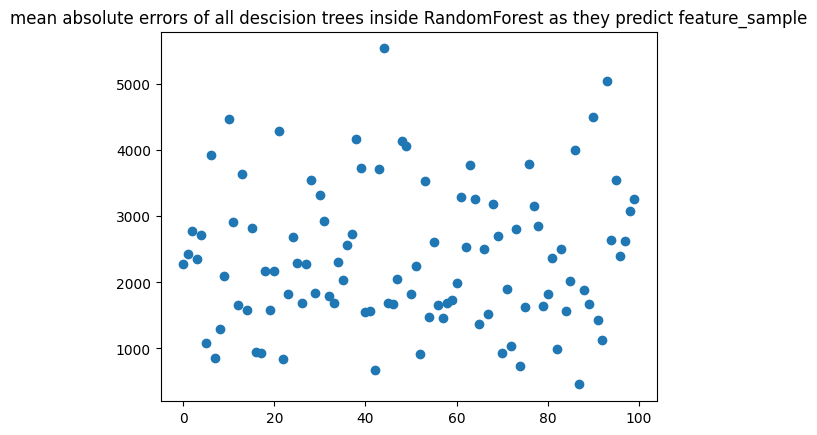

In [12]:
plt.scatter([x for x in range(100)], MAE_s)
plt.title('mean absolute errors of all descision trees inside RandomForest as they predict feature_sample')

In [13]:
## average mae_s
print(sum(MAE_s)/100)

2365.9031144289766


In [14]:
## Mean absolute error of main RF
mean_absolute_error(label_sample, RF.predict(feature_sample[Selected_Features]))

2169.632246575641